# Data Mining - A.A. 2025/2026
## Progetto Gruppo G3.3
### Membri:
- Masala Gabriele: 60/61/66245 (60/99/00004)
- Mantega Gabriele: 60/61/66251 (60/99/00006)
- Aresu Matteo: 60/99/00014

# 1 - Analisi del Dataset

In [9]:
# Dichiarazione Import
import pandas as pd
import numpy as np
import os
from sklearn import datasets
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction import text as sktext

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import matplotlib.pyplot as plt

In [92]:
# Direttive di Pandas per avere un output più leggibile
pd.set_option('display.max_colwidth', 100)

# Caricamento DataFrame da sklearn
categories = ['rec.autos', 'rec.sport.baseball', 'sci.electronics', 'sci.med', 'sci.space']
train_dataset = datasets.fetch_20newsgroups(subset='train', categories=categories)
test_dataset = datasets.fetch_20newsgroups(subset='test', categories=categories)
X_train = pd.DataFrame(train_dataset.data).rename(columns={0: 'raw_text'})
y_train = pd.DataFrame(train_dataset.target).rename(columns={0: 'category'})
X_test = pd.DataFrame(test_dataset.data).rename(columns={0: 'raw_text'})
y_test = pd.DataFrame(test_dataset.target).rename(columns={0: 'category'})

# Stampo la descrizione del dataset
#print(train_dataset.DESCR[90:845])

In [11]:
# Stampo il Training Set
#display(X_train)

# Stampo il Test Set
#display(y_train)

In [ ]:
# Stampo a schermo il primo record del Dataset
#print(X_train['raw_text'][0])

From: wright@duca.hi.com (David Wright)
Subject: Re: NATURAL ANTI-cancer/AIDS Remedies
Organization: Hitachi Computer Products, OSSD division
Lines: 16
NNTP-Posting-Host: duca.hi.com

In article <19604@pitt.UUCP> geb@cs.pitt.edu (Gordon Banks) writes:
|In article <1993Apr6.165840.5703@cnsvax.uwec.edu> mcelwre@cnsvax.uwec.edu writes:
|>     The biggest reason why the cost of medical care is so EXTREMELY high and
|>increasing is that NATURAL methods of treatment and even diagnosis are still
|>being SYSTEMATICALLY IGNORED and SUPPRESSED by the MONEY-GRUBBING and POWER-
|>MONGERING "medical" establishment.

|That's not the half of it.  Did you realize that all medical doctors have
|now been replaced by aliens?

Yup.  By the way, what planet are you from, and once you got here, did
you encounter those prejudices against foreign medical graduates?

  -- David Wright, Hitachi Computer Products (America), Inc.  Waltham, MA
     wright@hicomb.hi.com  ::  These are my opinions, not necessarily 


# 2 - Preprocessing

In [13]:
# FUNZIONI DI PREPROCESSING

# Load GloVe embeddings into a dictionary (presa da spot-intelligence)
def load_embeddings(file_path):
    embeddings = {}
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File {file_path} not found. Please check the path and try again.")
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            vector = np.asarray(values[1:], dtype='float32')
            embeddings[word] = vector
    return embeddings

# ---

# esegue: lowercase, tokenizzazione, rimozione della punteggiatura e delle stopword
def preprocess_text(text):
    # Converti il testo in minuscolo
    text = text.lower()
    
    # Rimuovi la punteggiatura
    text = ''.join(char for char in text if char.isalnum() or char.isspace())
    
    # Tokenizza il testo
    tokens = text.split()
    
    # Rimuovi le stopword (opzionale, puoi usare una lista di stopword)
    stopwords = sktext.ENGLISH_STOP_WORDS # stopwords di sklearn
    tokens = [tkn for tkn in tokens if tkn not in stopwords]
    
    return tokens

# ---

# Calcola l'embedding del documento come media degli embedding delle parole
def get_document_embedding(tokens, glove_embeddings):
    # Ottieni gli embedding per ogni parola nel documento
    word_embeddings = [glove_embeddings[token] for token in tokens if token in glove_embeddings.keys()] # Verifica se la parola ha un embedding disponibile
    
    # Calcola la media degli embedding per ottenere l'embedding del documento
    if word_embeddings:
        document_embedding = np.mean(word_embeddings, axis=0) 
    else:
        document_embedding = np.zeros(len(word_embeddings[0]))  # Se nessuna parola ha embedding, restituisci un vettore di zeri
    
    return document_embedding

# ---

# ...


## 2.1 Tf-Idf

In [14]:

# Utilizzo la classe TfidfVectorizer per convertire i record testuali in record numerici
tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_features=100)
tfidf_train = tfidf_vectorizer.fit_transform(X_train['raw_text'])
tfidf_test = tfidf_vectorizer.fit_transform(X_test['raw_text'])

## 2.2 Word Embeddings

In [15]:
# caricamento degli embeddings GloVe
glove_embeddings_path = 'glove.6B.100d.txt'  
glove_embeddings = load_embeddings(glove_embeddings_path)

# Preprocessamento del testo e calcolo degli embedding dei documenti
rows_train = []
for text in X_train['raw_text']:
    tokens = preprocess_text(text)
    rows_train.append(get_document_embedding(tokens, glove_embeddings))

rows_test = []
for text in X_test['raw_text']:
    tokens = preprocess_text(text)
    rows_test.append(get_document_embedding(tokens, glove_embeddings))

# Creazione di un DataFrame per visualizzare i risultati
glove_train = np.array(rows_train)
glove_test = np.array(rows_test)

# 3. Classificazione

In [16]:
# Inizializzazione classificatori (#todo parametri sparati, dobbiamo migliorarli)
classifiers = {
    'Decision Tree': DecisionTreeClassifier(max_depth=15, min_samples_split=5, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5, weights='distance'),
    'MLP': MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=50, learning_rate=1.0, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
}

# Inizializzazione delle rappresentazioni dei dati
representations = {
    'TF-IDF': (tfidf_train, tfidf_test),
    'GloVe': (glove_train, glove_test)
}


In [35]:
# Alleniamo e valutiamo tutti i modelli

repr_results = {}
for repr_name, splits in representations.items():
    print(f"\nNow testing on {repr_name} :3")
    X_train, X_test = splits
    
    performances = []
    
    for clf_name, clf in classifiers.items():
        
        # Allenamento modello
        print(f"Training {clf_name}...", end = "")
        clf.fit(X_train, y_train.values.ravel())
        y_pred = clf.predict(X_test)
        
        performances.append({
            'Model': clf_name,
            'Accuracy': accuracy_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
            'Recall': recall_score(y_test, y_pred, average='weighted', zero_division=0),
            'F1': f1_score(y_test, y_pred, average='weighted', zero_division=0)
        })
        print("OK")

    repr_results[repr_name] = performances


Now testing on TF-IDF :3
Training Decision Tree...OK
Training KNN...OK
Training MLP...OK
Training Random Forest...OK
Training AdaBoost...

/home/mantega/.local/lib/python3.9/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


OK
Training XGBoost...OK

Now testing on GloVe :3
Training Decision Tree...OK
Training KNN...OK
Training MLP...OK
Training Random Forest...OK
Training AdaBoost...

/home/mantega/.local/lib/python3.9/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


OK
Training XGBoost...OK


In [44]:
# Mostro i risultati :3
for repr_name, performances in repr_results.items():
    print("\n" + "="*70)
    print(f"Classification {repr_name} Summary")
    print("="*70)
    print((pd.DataFrame(performances).set_index('Model')))


Classification TF-IDF Summary
               Accuracy  Precision    Recall        F1
Model                                                 
Decision Tree  0.304150   0.351696  0.304150  0.302656
KNN            0.343117   0.353417  0.343117  0.346372
MLP            0.319332   0.352269  0.319332  0.321814
Random Forest  0.333502   0.384530  0.333502  0.322793
AdaBoost       0.279858   0.341024  0.279858  0.249845
XGBoost        0.297571   0.363676  0.297571  0.294773

Classification GloVe Summary
               Accuracy  Precision    Recall        F1
Model                                                 
Decision Tree  0.659413   0.659423  0.659413  0.658875
KNN            0.876518   0.878011  0.876518  0.876956
MLP            0.890688   0.890772  0.890688  0.890585
Random Forest  0.872470   0.873569  0.872470  0.872849
AdaBoost       0.756579   0.759153  0.756579  0.757324
XGBoost        0.872470   0.874036  0.872470  0.872990


<Figure size 640x480 with 0 Axes>

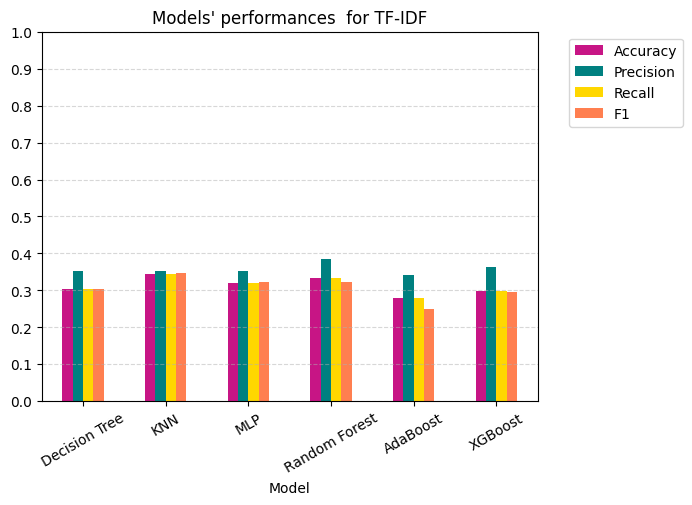

<Figure size 640x480 with 0 Axes>

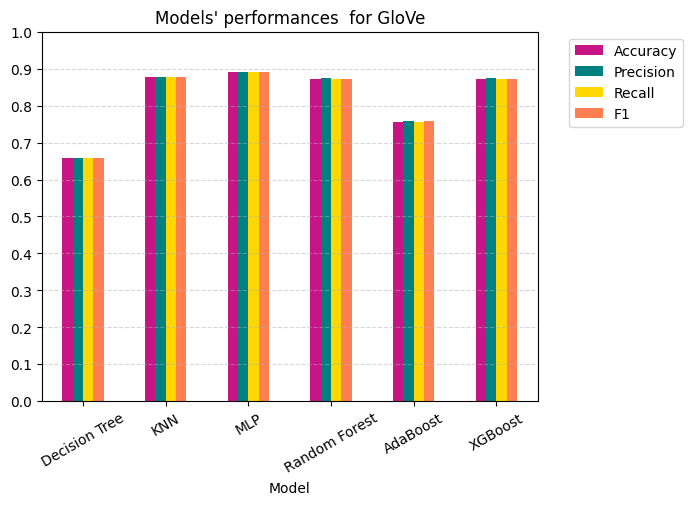

In [87]:
metrics_colors = [
    'mediumvioletred', 
    'teal', 
    'gold', 
    'coral'
]

for repr_name, performances in repr_results.items():
    plt.figure()
    
    performances_df = pd.DataFrame(performances).set_index('Model')
    performances_df.plot.bar(color=metrics_colors).legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.xticks(rotation=30)
    plt.ylim([0,1])
    plt.yticks(np.arange(0,1.1,step=0.1))
    plt.tick_params('x')
    plt.grid(True, axis='y', linestyle='--', alpha=0.5)
    plt.title(f'Models\' performances  for {repr_name}')
    plt.show()

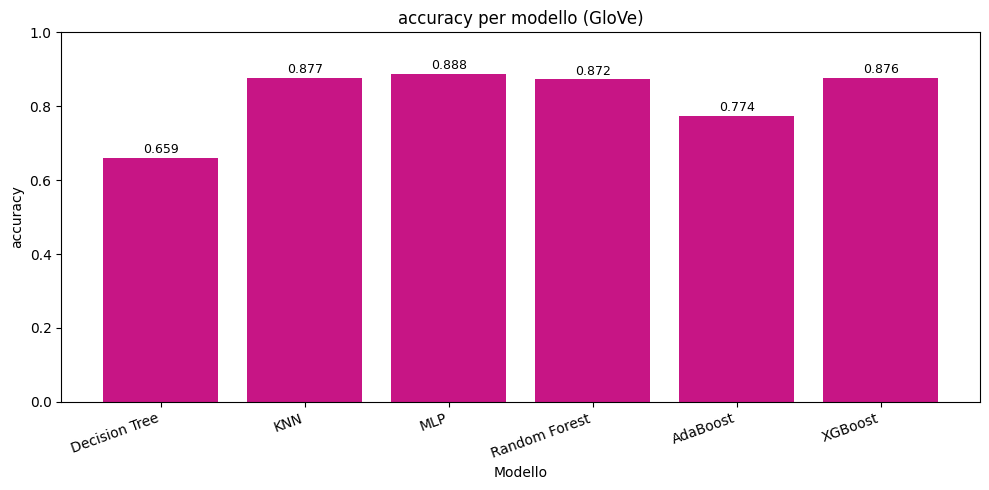

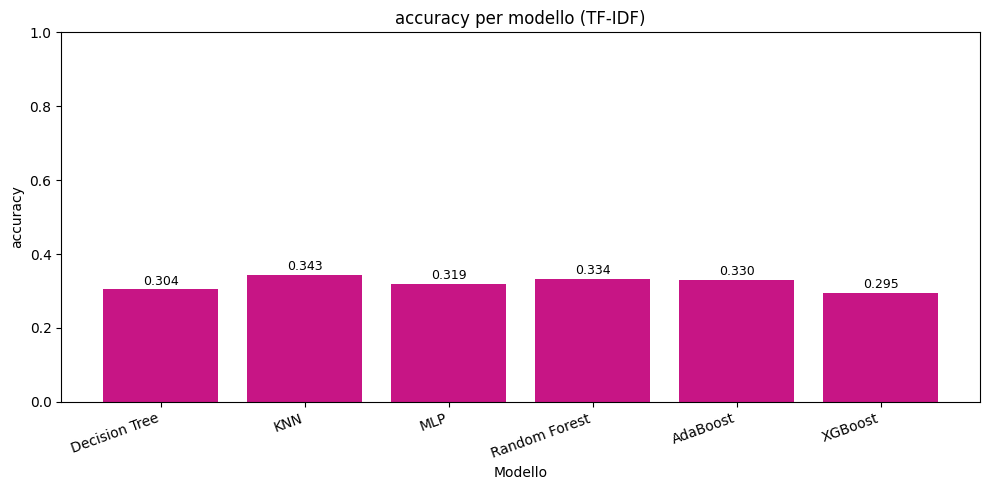

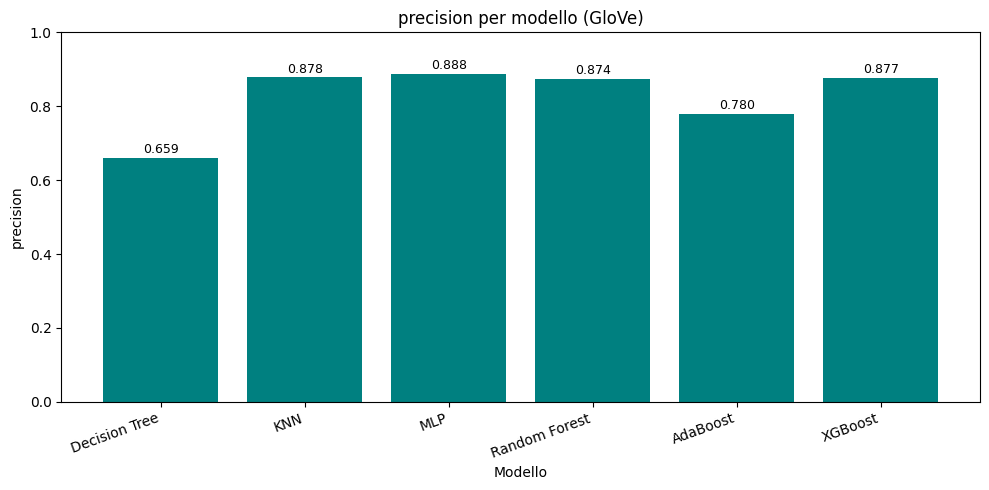

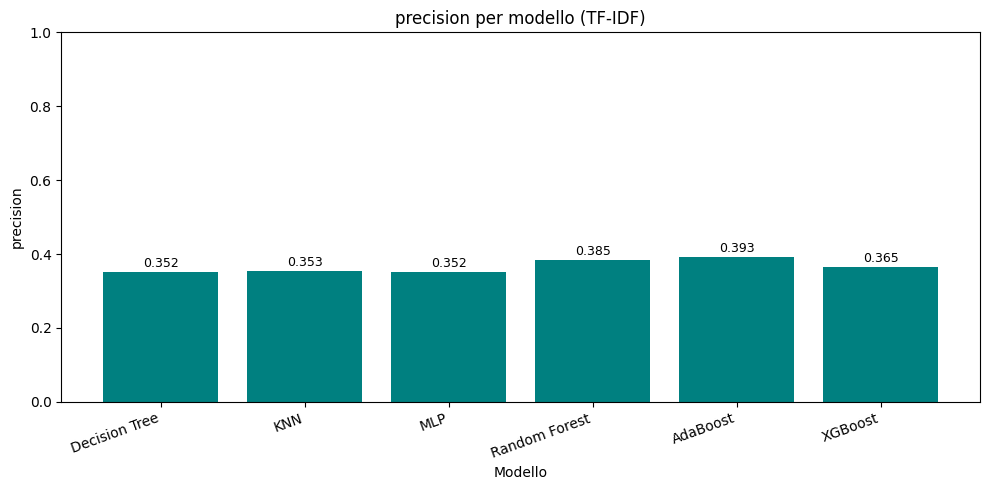

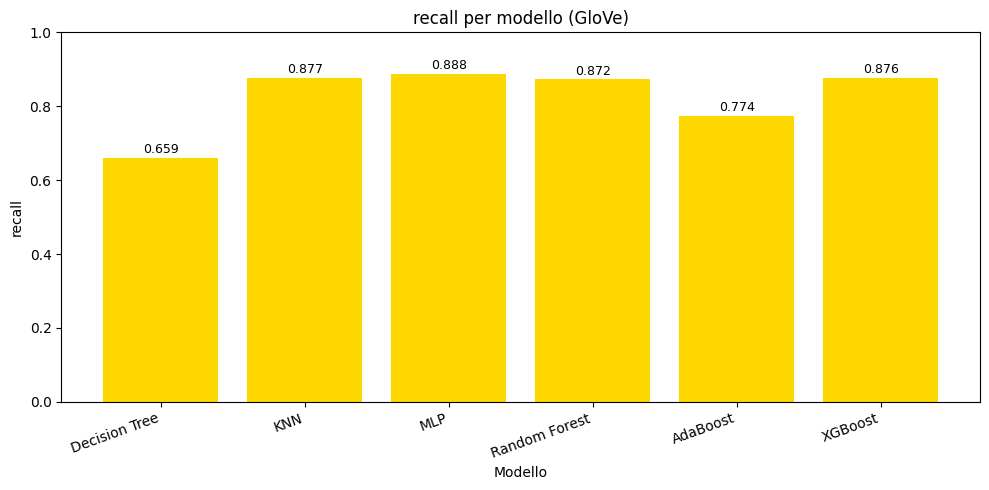

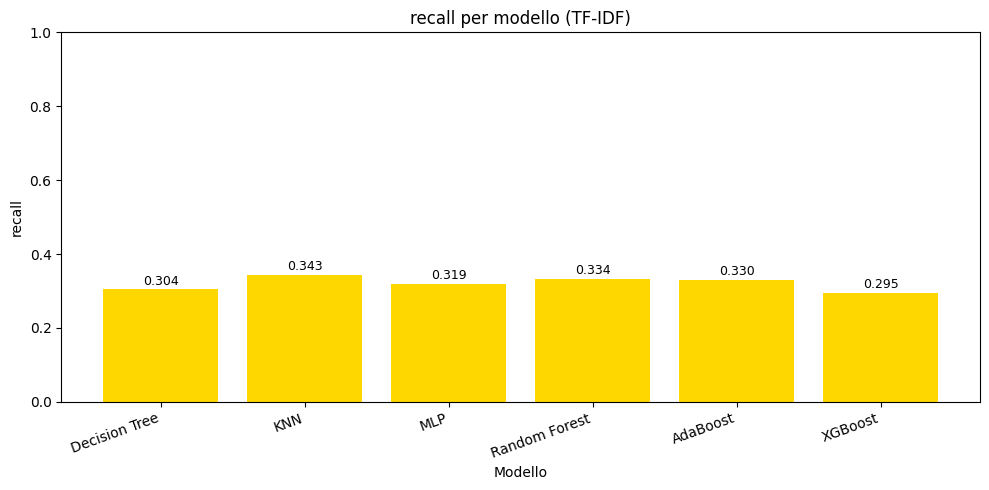

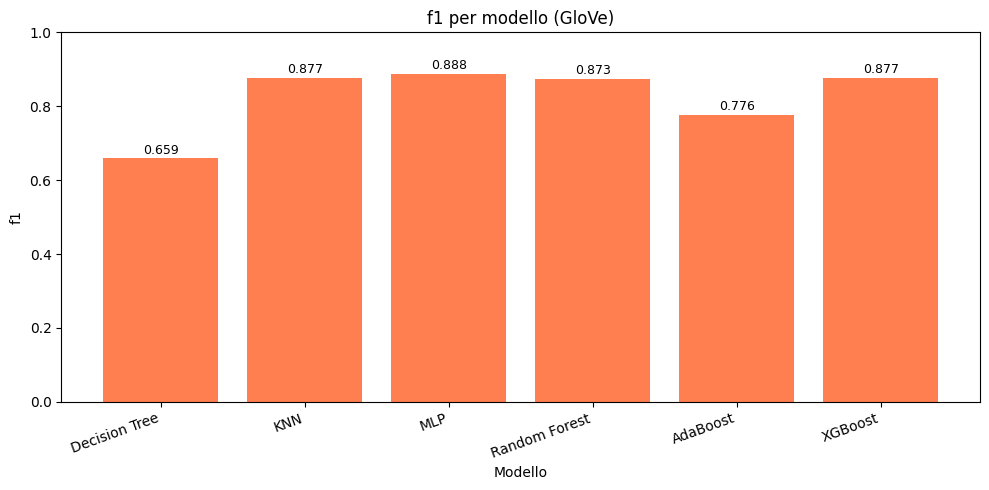

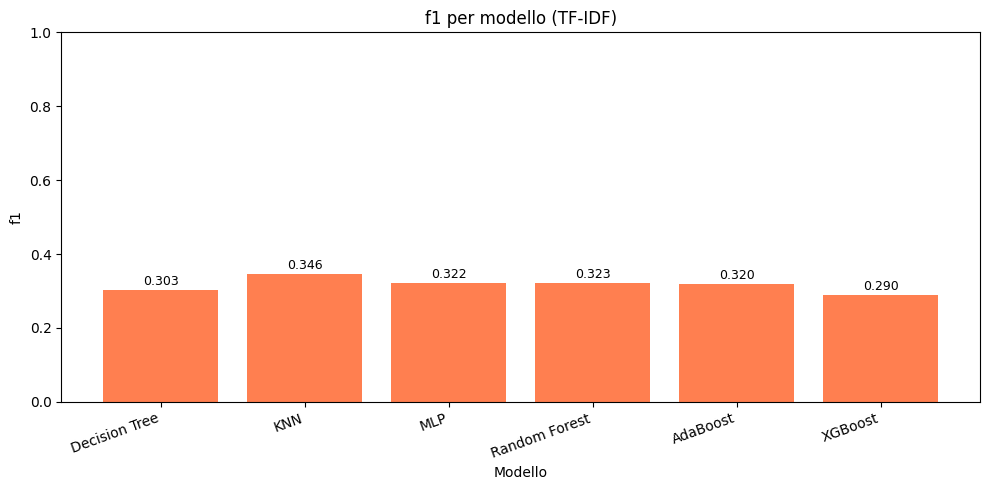

In [ ]:
# Definizione funzione che restituisce una metrica scelta
def get_metric (which):

    # Metrica per modello per ogni representazione icsdì XD
    metric_by_repr = {
        repr: {model: metrics[which] for model, metrics in perf.items()}
        for repr, perf in results
    }
    
    return metric_by_repr

# Scegliamo un vettore di colori 
colors = {
    'accuracy': 'mediumvioletred', 
    'precision': 'teal', 
    'recall': 'gold', 
    'f1': 'coral'
}

# Ciclo di stampa dei grafici
for metric in ['accuracy', 'precision', 'recall', 'f1']:

    for repr in ['GloVe', 'TF-IDF']:

        metric_per_model = get_metric(metric)[repr]
        models = list(metric_per_model.keys())
        metrics = list(metric_per_model.values())

        plt.figure(figsize=(10, 5))
        bars = plt.bar(models, metrics, color=colors[metric])

        plt.title(f'{metric} per modello ({repr})')
        plt.xlabel('Modello')
        plt.ylabel(f'{metric}')
        plt.ylim(0, 1)
        plt.xticks(rotation=20, ha='right')

        # Etichette sopra le barre
        for bar, mtr in zip(bars, metrics):
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f"{mtr:.3f}",
                ha='center',
                va='bottom',
                fontsize=9
            )

        plt.tight_layout()
        plt.show()